<a href="https://colab.research.google.com/github/Sudarshanmukhekar/Build-and-Deploy-Ecommerce-Website/blob/main/Copy_of_PMA_PRACTICAL_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Data:
    Student_ID Department  Marks  Attendance Grade
0           1         CS     99          74     A
1           2         IT     98          79     B
2           3       EXTC     40          91     C
3           4         CS     41          93     A
4           5         IT     48          82     B

Labor Data:
    Labor_ID Region Skill_Type  Working_Hours  Salary
0         1  North  Technical             11   27209
1         2  South    Skilled              6   45328
2         3   East  Unskilled              8   38480
3         4   West  Technical              6   12765
4         5  North    Skilled              8   43865

Normalized Student Data:
    Student_ID Department  Marks  Attendance Grade  Normalized_Marks  \
0           1         CS     99          74     A          1.000000   
1           2         IT     98          79     B          0.983051   
2           3       EXTC     40          91     C          0.000000   
3           4         CS     41          9

/tmp/ipykernel_4414/2196761631.py:86: FutureWarning: The provided callable <function mean at 0x7c8389a49620> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  cube = pd.pivot_table(


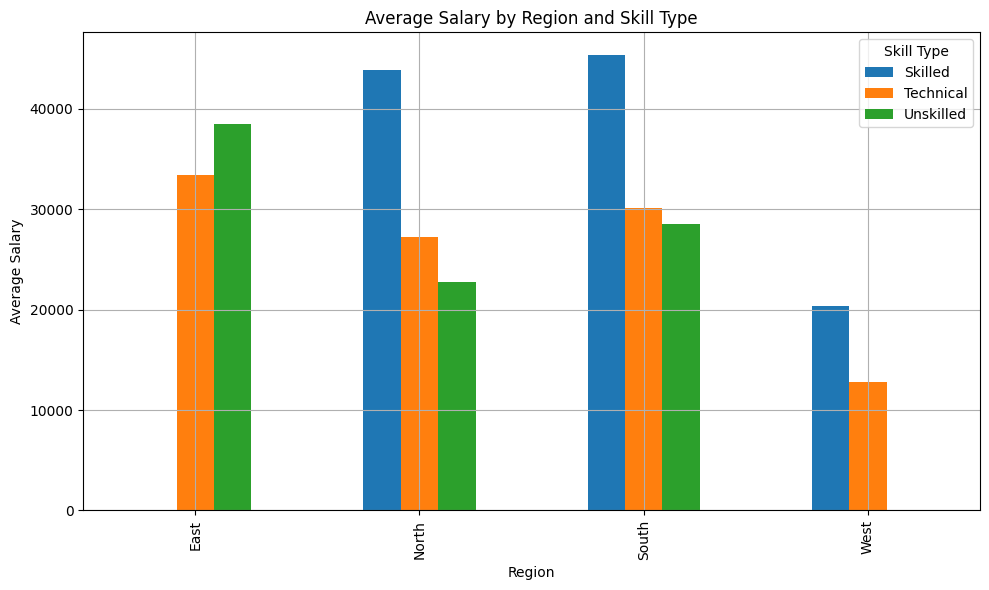

In [ ]:
# ================================
# Assignment No. 1 Practical
# Data Preprocessing + Data Cube
# ================================

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# ================================
# Step 2: Create Student Dataset
# ================================
student_df = pd.DataFrame({
    'Student_ID': range(1, 11),
    'Department': ['CS', 'IT', 'EXTC', 'CS', 'IT', 'EXTC', 'CS', 'IT', 'EXTC', 'CS'],
    'Marks': np.random.randint(40, 100, 10),
    'Attendance': np.random.randint(60, 100, 10),
    'Grade': ['A', 'B', 'C', 'A', 'B', 'C', 'A', 'B', 'C', 'A']
})

# Save dataset
student_df.to_csv('student_data.csv', index=False)

# ================================
# Step 3: Create Labor Dataset
# ================================
labor_df = pd.DataFrame({
    'Labor_ID': range(1, 11),
    'Region': ['North', 'South', 'East', 'West', 'North', 'South', 'East', 'West', 'North', 'South'],
    'Skill_Type': ['Technical', 'Skilled', 'Unskilled', 'Technical', 'Skilled', 'Unskilled', 'Technical', 'Skilled', 'Unskilled', 'Technical'],
    'Working_Hours': np.random.randint(6, 12, 10),
    'Salary': np.random.randint(10000, 50000, 10)
})

# Save dataset
labor_df.to_csv('labor_data.csv', index=False)

# ================================
# Step 4: Load the datasets
# ================================
student_df = pd.read_csv('student_data.csv')
labor_df = pd.read_csv('labor_data.csv')

print("Student Data:\n", student_df.head())
print("\nLabor Data:\n", labor_df.head())

# ================================
# Step 5: Data Cleaning
# ================================
# Handle missing values
student_df.fillna(student_df.mean(numeric_only=True), inplace=True)
labor_df.dropna(subset=['Salary'], inplace=True)

# Remove duplicates
student_df.drop_duplicates(inplace=True)
labor_df.drop_duplicates(inplace=True)

# ================================
# Step 6: Data Transformation
# ================================
student_df['Grade'] = student_df['Grade'].astype('category')

# ================================
# Step 7: Normalization
# ================================
scaler = MinMaxScaler()

# Student normalization
student_df[['Normalized_Marks', 'Normalized_Attendance']] = scaler.fit_transform(
    student_df[['Marks', 'Attendance']]
)

# Labor normalization
labor_df[['Normalized_Hours', 'Normalized_Salary']] = scaler.fit_transform(
    labor_df[['Working_Hours', 'Salary']]
)

print("\nNormalized Student Data:\n", student_df.head())
print("\nNormalized Labor Data:\n", labor_df.head())

# ================================
# Step 8: Create Data Cube
# ================================
cube = pd.pivot_table(
    labor_df,
    values='Salary',
    index='Region',
    columns='Skill_Type',
    aggfunc=np.mean
)

print("\nData Cube:\n", cube)

# ================================
# Step 9: OLAP Operations
# ================================
# Slice
slice_tech = cube['Technical']
print("\nSlice (Technical):\n", slice_tech)

# Dice
dice = cube.loc[['North', 'West'], ['Technical', 'Skilled']]
print("\nDice (North & West, Technical & Skilled):\n", dice)

# ================================
# Step 10: Visualization
# ================================
cube.plot(kind='bar', figsize=(10, 6))

plt.title("Average Salary by Region and Skill Type")
plt.xlabel("Region")
plt.ylabel("Average Salary")
plt.legend(title="Skill Type")
plt.grid(True)
plt.tight_layout()
plt.show()


Dataset:
    Feature1  Feature2
0 -7.726421 -8.394957
1  5.453396  0.742305
2 -2.978672  9.556846
3  6.042673  0.571319
4 -6.521840 -6.319325


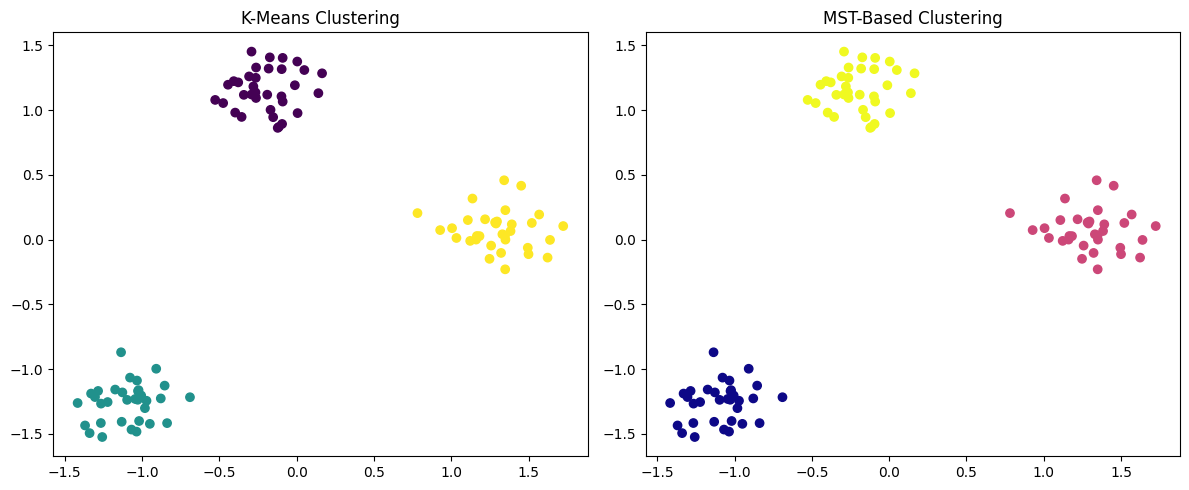


--- K-Means Evaluation ---
Silhouette Score: 0.8492776082622019
Davies-Bouldin Index: 0.21011260018963537
Inertia: 5.59010934122747

--- MST Clustering Evaluation ---
Silhouette Score: 0.8492776082622019
Davies-Bouldin Index: 0.21011260018963537


In [ ]:
# =========================================
# Assignment No. 2 Practical
# K-Means + MST Clustering + Evaluation
# =========================================

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.datasets import make_blobs

from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import minimum_spanning_tree

import networkx as nx

# =========================================
# Step 2: Create Sample Dataset
# =========================================
X, _ = make_blobs(n_samples=100, centers=3, n_features=2, random_state=42)

data = pd.DataFrame(X, columns=['Feature1', 'Feature2'])
print("Dataset:\n", data.head())

# =========================================
# Step 3: Data Preprocessing (Scaling)
# =========================================
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

# =========================================
# Step 4: Apply K-Means Clustering
# =========================================
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_data)

# =========================================
# Step 5: MST-Based Clustering
# =========================================

# Distance matrix
distance_matrix = squareform(pdist(scaled_data))

# Minimum Spanning Tree
mst_matrix = minimum_spanning_tree(distance_matrix)

# Convert to graph
G = nx.from_scipy_sparse_array(mst_matrix)

# =========================================
# Step 6: Remove (K-1) largest edges
# =========================================
k = 3  # number of clusters

edges = sorted(G.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)

for i in range(k - 1):
    G.remove_edge(edges[i][0], edges[i][1])

# =========================================
# Step 7: Extract MST Cluster Labels
# =========================================
components = list(nx.connected_components(G))

mst_labels = np.zeros(len(scaled_data), dtype=int)

for i, comp in enumerate(components):
    for idx in comp:
        mst_labels[idx] = i

# =========================================
# Step 8: Visualization
# =========================================
plt.figure(figsize=(12, 5))

# K-Means Plot
plt.subplot(1, 2, 1)
plt.scatter(scaled_data[:, 0], scaled_data[:, 1], c=kmeans_labels, cmap='viridis')
plt.title('K-Means Clustering')

# MST Plot
plt.subplot(1, 2, 2)
plt.scatter(scaled_data[:, 0], scaled_data[:, 1], c=mst_labels, cmap='plasma')
plt.title('MST-Based Clustering')

plt.tight_layout()
plt.show()

# =========================================
# Step 9: Cluster Evaluation
# =========================================

# K-Means Evaluation
print("\n--- K-Means Evaluation ---")
print("Silhouette Score:", silhouette_score(scaled_data, kmeans_labels))
print("Davies-Bouldin Index:", davies_bouldin_score(scaled_data, kmeans_labels))
print("Inertia:", kmeans.inertia_)

# MST Evaluation
print("\n--- MST Clustering Evaluation ---")
print("Silhouette Score:", silhouette_score(scaled_data, mst_labels))
print("Davies-Bouldin Index:", davies_bouldin_score(scaled_data, mst_labels))


Dataset Preview:
    MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  

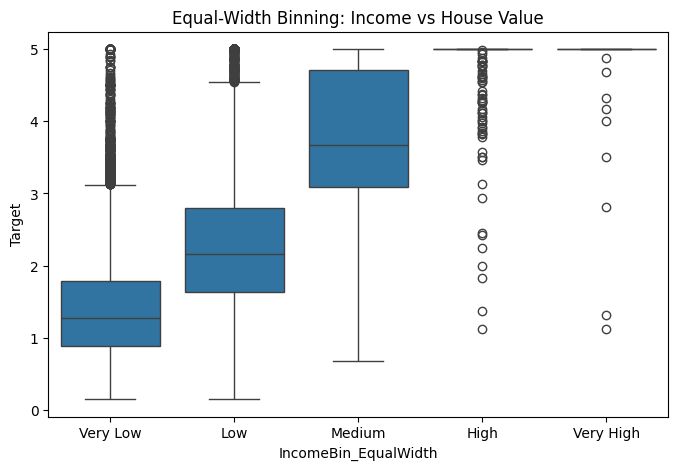

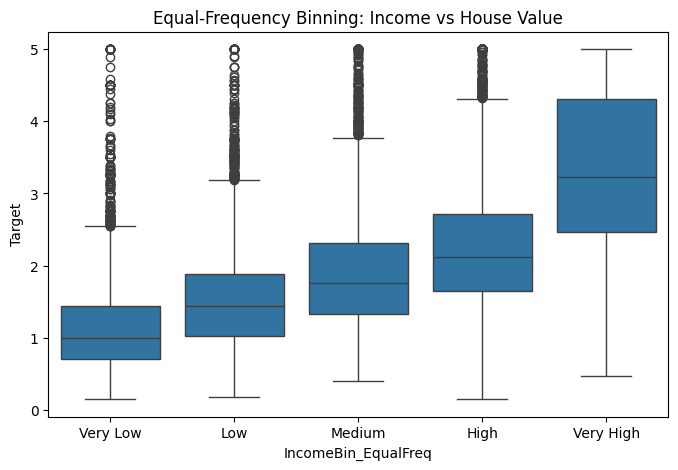


--- Model Evaluation ---
R² Score: 0.45885918903846656
Mean Squared Error (MSE): 0.7091157771765549


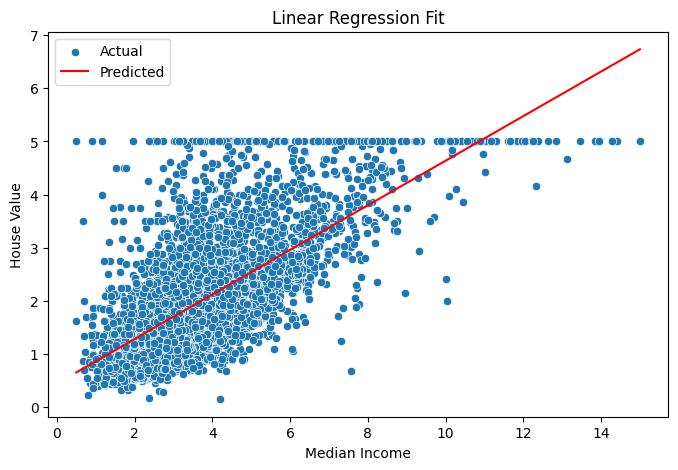

In [ ]:
# =========================================
# Assignment No. 3 Practical
# Binning + Linear Regression
# =========================================

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.datasets import fetch_california_housing

# =========================================
# Step 2: Load Dataset
# =========================================
data = fetch_california_housing()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['Target'] = data.target

print("Dataset Preview:\n", df.head())
print("\nDataset Info:\n")
print(df.info())

# =========================================
# Step 3: Check Missing Values
# =========================================
print("\nMissing Values:\n", df.isnull().sum())

# =========================================
# Step 4: Binning (Equal-Width)
# =========================================
df['IncomeBin_EqualWidth'] = pd.cut(
    df['MedInc'],
    bins=5,
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)

# Visualization
plt.figure(figsize=(8, 5))
sns.boxplot(x='IncomeBin_EqualWidth', y='Target', data=df)
plt.title("Equal-Width Binning: Income vs House Value")
plt.show()

# =========================================
# Step 5: Binning (Equal-Frequency)
# =========================================
df['IncomeBin_EqualFreq'] = pd.qcut(
    df['MedInc'],
    q=5,
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)

# Visualization
plt.figure(figsize=(8, 5))
sns.boxplot(x='IncomeBin_EqualFreq', y='Target', data=df)
plt.title("Equal-Frequency Binning: Income vs House Value")
plt.show()

# =========================================
# Step 6: Linear Regression
# =========================================
X = df[['MedInc']]   # Independent variable
y = df['Target']     # Dependent variable

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_pred = lr.predict(X_test)

# =========================================
# Step 7: Evaluation
# =========================================
print("\n--- Model Evaluation ---")
print("R² Score:", r2_score(y_test, y_pred))
print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))

# =========================================
# Step 8: Visualization (Regression Line)
# =========================================
plt.figure(figsize=(8, 5))

sns.scatterplot(x=X_test['MedInc'], y=y_test, label='Actual')
sns.lineplot(x=X_test['MedInc'], y=y_pred, color='red', label='Predicted')

plt.title('Linear Regression Fit')
plt.xlabel('Median Income')
plt.ylabel('House Value')
plt.legend()

plt.show()


Dataset:
    Annual Income (k$)  Spending Score (1-100)
0            7.438541                2.683919
1           -6.438815               10.247140
2           -8.856698                5.977641
3          -11.010454                5.212327
4           -7.763674               -5.605706


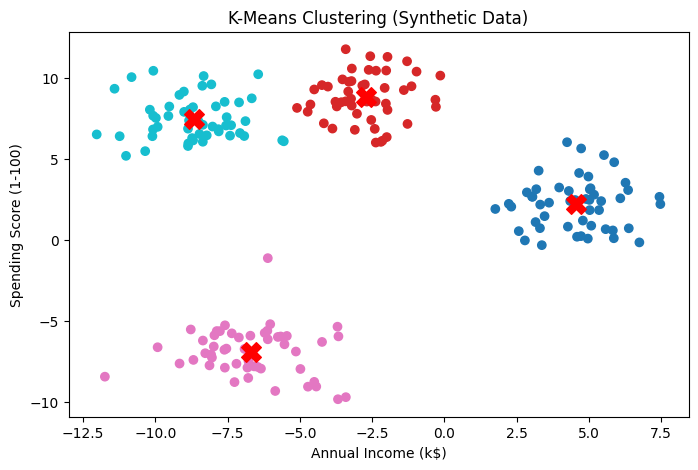

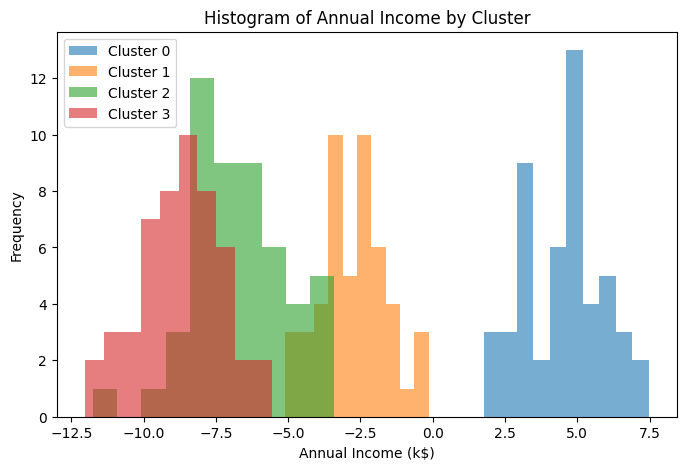

In [ ]:
# =========================================
# Assignment No. 4 Practical
# Clustering + Histogram Visualization
# =========================================

# Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# =========================================
# Step 2: Generate Synthetic Dataset
# =========================================
X, _ = make_blobs(n_samples=200, centers=4, cluster_std=1.5, random_state=42)

# Convert to DataFrame
df = pd.DataFrame(X, columns=['Annual Income (k$)', 'Spending Score (1-100)'])

print("Dataset:\n", df.head())

# =========================================
# Step 3: Preprocess Data
# =========================================
X_values = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# =========================================
# Step 4: Apply K-Means Clustering
# =========================================
kmeans = KMeans(n_clusters=4, random_state=42)
y_kmeans = kmeans.fit_predict(X_values)

# =========================================
# Step 5: Visualize Clusters
# =========================================
plt.figure(figsize=(8, 5))

plt.scatter(X_values[:, 0], X_values[:, 1], c=y_kmeans, cmap='tab10')
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=200,
    c='red',
    marker='X'
)

plt.title("K-Means Clustering (Synthetic Data)")
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

plt.show()

# =========================================
# Step 6: Convert Clusters to Histogram
# =========================================
df['Cluster'] = y_kmeans

plt.figure(figsize=(8, 5))

for cluster_id in sorted(df['Cluster'].unique()):
    cluster_data = df[df['Cluster'] == cluster_id]

    plt.hist(
        cluster_data['Annual Income (k$)'],
        bins=10,
        alpha=0.6,
        label=f'Cluster {cluster_id}'
    )

plt.xlabel('Annual Income (k$)')
plt.ylabel('Frequency')
plt.title('Histogram of Annual Income by Cluster')
plt.legend()

plt.show()


Dataset:
      Outlook Temperature Humidity    Wind PlayTennis
0      Sunny         Hot     High    Weak         No
1      Sunny         Hot     High  Strong         No
2   Overcast         Hot     High    Weak        Yes
3       Rain        Mild     High    Weak        Yes
4       Rain        Cool   Normal    Weak        Yes
5       Rain        Cool   Normal  Strong         No
6   Overcast        Mild     High  Strong        Yes
7      Sunny         Hot     High    Weak         No
8      Sunny        Cool   Normal    Weak        Yes
9       Rain        Mild   Normal    Weak        Yes
10     Sunny        Mild   Normal  Strong        Yes
11  Overcast        Mild     High  Strong        Yes
12  Overcast         Hot   Normal    Weak        Yes
13      Rain        Mild     High  Strong         No


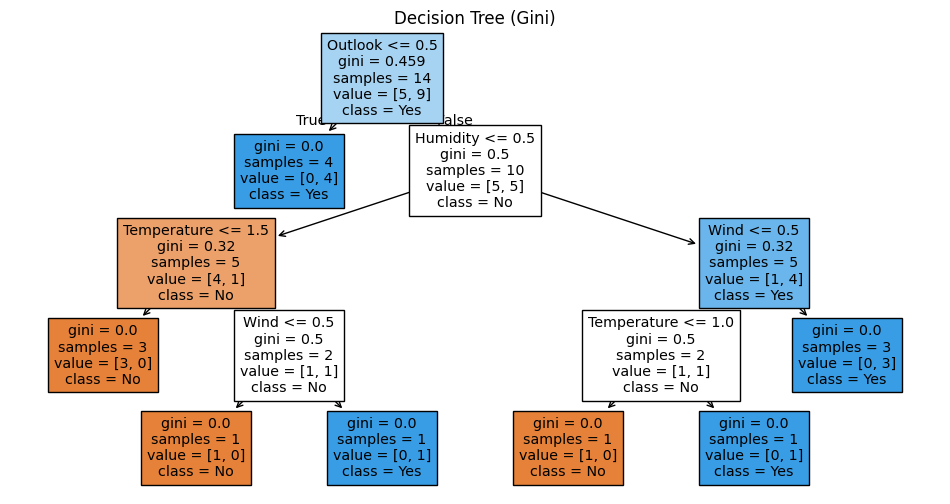

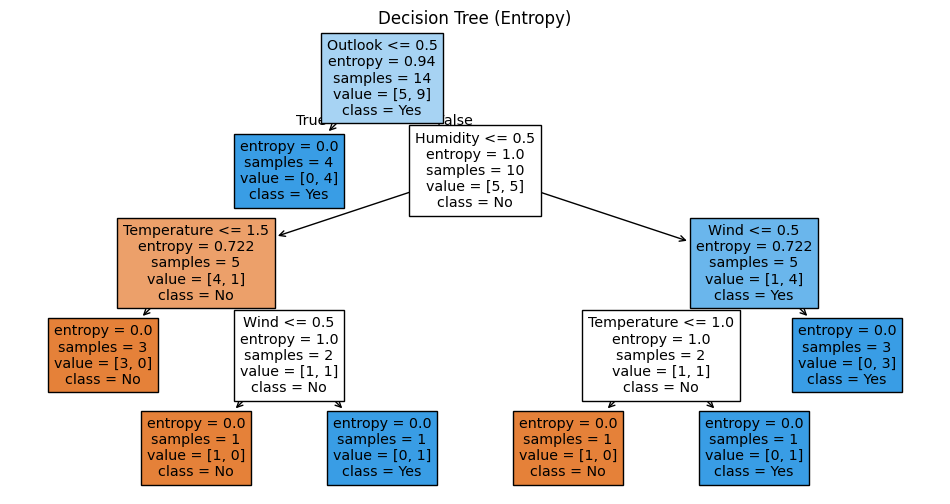


Predictions:
Decision Tree (Gini): No
Decision Tree (Entropy): No
Random Forest: No


In [ ]:
# =========================================
# Assignment No. 5 Practical
# Decision Tree + Random Forest
# =========================================

# Step 1: Import Libraries
import pandas as pd

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt

# =========================================
# Step 2: Create Play Tennis Dataset
# =========================================
data = {
    'Outlook': ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast','Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
    'Temperature': ['Hot','Hot','Hot','Mild','Cool','Cool','Mild','Hot','Cool','Mild','Mild','Mild','Hot','Mild'],
    'Humidity': ['High','High','High','High','Normal','Normal','High','High','Normal','Normal','Normal','High','Normal','High'],
    'Wind': ['Weak','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
    'PlayTennis': ['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No']
}

df = pd.DataFrame(data)
print("Dataset:\n", df)

# =========================================
# Step 3: Encode Categorical Data
# =========================================
X = df.drop('PlayTennis', axis=1)
y = df['PlayTennis']

label_encoders = {}

for col in X.columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

le_target = LabelEncoder()
y_enc = le_target.fit_transform(y)

# =========================================
# Step 4: Train Models
# =========================================

# Decision Tree (Gini)
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_gini.fit(X, y_enc)

# Decision Tree (Entropy)
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_entropy.fit(X, y_enc)

# Random Forest
rf = RandomForestClassifier(n_estimators=10, random_state=42)
rf.fit(X, y_enc)

# =========================================
# Step 5: Visualize Decision Trees
# =========================================
plt.figure(figsize=(12, 6))
plot_tree(dt_gini, feature_names=X.columns, class_names=le_target.classes_, filled=True)
plt.title("Decision Tree (Gini)")
plt.show()

plt.figure(figsize=(12, 6))
plot_tree(dt_entropy, feature_names=X.columns, class_names=le_target.classes_, filled=True)
plt.title("Decision Tree (Entropy)")
plt.show()

# =========================================
# Step 6: Test Sample
# =========================================
test_sample = {
    'Outlook': 'Sunny',
    'Temperature': 'Cool',
    'Humidity': 'High',
    'Wind': 'Strong'
}

test_df = pd.DataFrame([test_sample])

# Encode test data
for col in test_df.columns:
    test_df[col] = label_encoders[col].transform(test_df[col])

# =========================================
# Step 7: Predictions
# =========================================
gini_pred = dt_gini.predict(test_df)
entropy_pred = dt_entropy.predict(test_df)
rf_pred = rf.predict(test_df)

print("\nPredictions:")

print("Decision Tree (Gini):", le_target.inverse_transform(gini_pred)[0])
print("Decision Tree (Entropy):", le_target.inverse_transform(entropy_pred)[0])
print("Random Forest:", le_target.inverse_transform(rf_pred)[0])


Dataset not found → Creating synthetic dataset
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin        BMI  \
0            6      165             72             20       53  37.591600   
1            3       90            119             38      239  31.059034   
2            7      191            117             45      242  32.940251   
3            4       95             66             34      162  35.361767   
4            6      176            116             30      281  28.965728   

   DiabetesPedigreeFunction  Age  Outcome  
0                  1.095098   61        0  
1                  0.304839   63        0  
2                  2.492498   21        1  
3                  1.305268   54        1  
4                  1.528924   61        0  
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4875 - loss: 0.8601 - val_accuracy: 0.5000 - val_loss: 0.9523
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5063 - loss: 0.7993 - val_accuracy: 0.5000 - val_loss: 0.8849
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5000 - loss: 0.7603 - val_accuracy: 0.5000 - val_loss: 0.8340
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5063 - loss: 0.7330 - val_accuracy: 0.5250 - val_loss: 0.8009
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5437 - loss: 0.7143 - val_accuracy: 0.5250 - val_loss: 0.7780
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5625 - loss: 0.6994 - val_accuracy: 0.5250 - val_loss: 0.7660
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5437 - loss: 0.6895 - val_accuracy: 0.5000 - val_loss: 0.7561
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5688 - loss: 0.6809 - val_accuracy: 0.4750 - val_loss: 0.7475
Ep

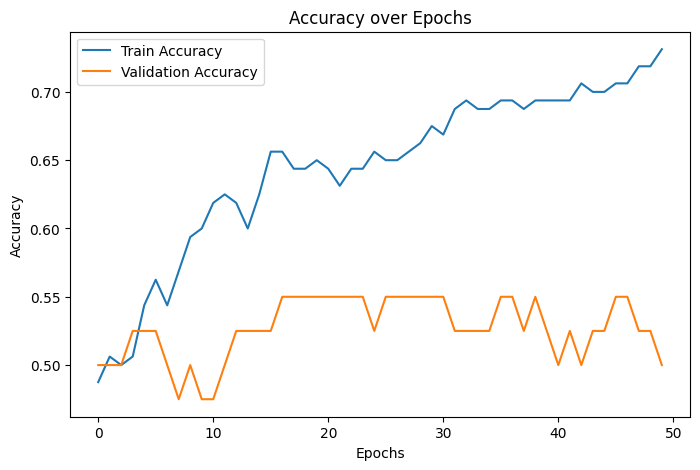

In [ ]:
# =========================================
# Assignment No. 9 Practical
# Artificial Neural Network (Healthcare)
# =========================================

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# =========================================
# Step 2: Load Dataset (Auto / Synthetic)
# =========================================

# Try loading real dataset (if available)
try:
    df = pd.read_csv("pima-indians-diabetes.csv")
    print("Dataset Loaded Successfully")
except:
    print("Dataset not found → Creating synthetic dataset")

    # Create synthetic healthcare dataset
    np.random.seed(42)
    df = pd.DataFrame({
        'Pregnancies': np.random.randint(0, 10, 200),
        'Glucose': np.random.randint(80, 200, 200),
        'BloodPressure': np.random.randint(60, 120, 200),
        'SkinThickness': np.random.randint(10, 50, 200),
        'Insulin': np.random.randint(50, 300, 200),
        'BMI': np.random.uniform(18, 40, 200),
        'DiabetesPedigreeFunction': np.random.uniform(0.1, 2.5, 200),
        'Age': np.random.randint(20, 70, 200),
        'Outcome': np.random.randint(0, 2, 200)
    })

print(df.head())

# =========================================
# Step 3: Split Features & Target
# =========================================
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# =========================================
# Step 4: Train-Test Split + Scaling
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================================
# Step 5: Build ANN Model
# =========================================
model = Sequential()

model.add(Dense(12, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# =========================================
# Step 6: Compile & Train
# =========================================
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=10,
    verbose=1
)

# =========================================
# Step 7: Evaluate Model
# =========================================
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"\nTest Accuracy: {accuracy*100:.2f}%")

# Predictions
y_pred = (model.predict(X_test) > 0.5).astype(int)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# =========================================
# Step 8: Plot Accuracy
# =========================================
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()
